# CSP — BCI Competition IV 2a

Experimentos completos:
1. **LOSO** sobre datos combinados T+E — 2 clases
2. **LOSO** sobre datos combinados T+E — 4 clases
3. **Ablación de canales** (11ch vs 22ch) con la mejor config por clase
4. **Within-subject T→E** (estándar competición) con la mejor config por clase

Flujo:
- LOSO usa T+E combinados (~576 trials/sujeto) → generalización entre sujetos.
- Within-subject usa T para entrenar y E para evaluar → comparable con literatura.
- No se aplica filtro Laplaciano: CSP ya aprende filtros espaciales óptimos de los datos,
  por lo que el Laplaciano es redundante e incluso puede perjudicar al limitar la información espacial disponible.

## 0 · Imports

In [1]:
import sys
import os
import random
import numpy as np
import pandas as pd
import mne
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from mne.decoding import CSP

PROJECT_ROOT = os.path.abspath('..')
sys.path.append(PROJECT_ROOT)

from src.load_data_BCICIV import load_all_subjects, load_combined
from src.train_CSP import train_CSP
from src.preprocess import normalize_trial
from src.visualization_eeg import visualize_csp

mne.set_log_level('WARNING')
np.random.seed(42)
random.seed(42)

/home/alumno/Desktop/datos/a/Biosignal-ML-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Configuración de rutas

In [2]:
DATA_DIR  = '../datasets/BCICIV_2a_gdf'
LABEL_DIR = '../datasets/BCICIV_2a_gdf/true_labels'

## 2 · Pipelines y param grids

Dos clasificadores: LDA y SVM-RBF. El param grid incluye `n_components` y regularización de CSP.

In [3]:
def to_float64(X):
    return X.astype(np.float64)

float64_transformer = FunctionTransformer(to_float64)
norm_transformer    = FunctionTransformer(normalize_trial)

# CSP + LDA
pipe_lda = Pipeline([
    ('to_float64', float64_transformer),
    ('norm',       norm_transformer),
    ('csp',        CSP(log=True, norm_trace=False)),
    ('clf',        LinearDiscriminantAnalysis()),
])
param_grid_lda = {
    'csp__n_components': [2, 4],
    'csp__reg':          ['ledoit_wolf', 'oas'],
    'clf__solver':       ['svd', 'lsqr'],
}

# CSP + SVM
pipe_svm = Pipeline([
    ('to_float64', float64_transformer),
    ('norm',       norm_transformer),
    ('csp',        CSP(log=True, norm_trace=False)),
    ('clf',        SVC(kernel='rbf')),
])
param_grid_svm = {
    'csp__n_components': [2, 4],
    'csp__reg':          ['ledoit_wolf', 'oas'],
    'clf__C':            [0.5, 1, 5],
    'clf__gamma':        ['scale'],
}

CLASSIFIERS = [
    {'name': 'LDA', 'pipe': pipe_lda, 'param_grid': param_grid_lda},
    {'name': 'SVM', 'pipe': pipe_svm, 'param_grid': param_grid_svm},
]

## 3 · Grid de experimentos

Cada entrada define una configuración de features. Se ejecutan para 2 y 4 clases × LDA y SVM.

| Config | Descripción |
|--------|-------------|
| `base` | Señal filtrada 8-30 Hz, normalizada |
| `mu_band` | Solo banda mu (8-12 Hz) |
| `multiband` | Canales concatenados mu + beta (8-12 + 13-30 Hz) |

In [4]:
EXPERIMENT_GRID = [
    {'name': 'base',       'use_multiband': False, 'mu_only': False},
    {'name': 'multiband',  'use_multiband': True,  'mu_only': False},
]

n_runs = len(EXPERIMENT_GRID) * len(CLASSIFIERS) * 2  # ×2 clases
print(f'{len(EXPERIMENT_GRID)} feature configs × {len(CLASSIFIERS)} classifiers × 2 classes = {n_runs} runs LOSO')

2 feature configs × 2 classifiers × 2 classes = 8 runs LOSO


## 4 · Carga de datos combinados T+E (para LOSO)

Se cargan las variantes base y multiband para 11ch. La de 22ch se carga en la sección de ablación.

In [5]:
print('Loading 11ch data (base + multiband) for 2 and 4 classes...')

X2,    y2,    subj2    = load_combined(DATA_DIR, LABEL_DIR, n_classes=2)
X4,    y4,    subj4    = load_combined(DATA_DIR, LABEL_DIR, n_classes=4)

X2_mb, y2_mb, subj2_mb = load_combined(DATA_DIR, LABEL_DIR, n_classes=2, use_multiband=True)
X4_mb, y4_mb, subj4_mb = load_combined(DATA_DIR, LABEL_DIR, n_classes=4, use_multiband=True)

# Vista previa de shapes
print(f'Base  2cls: {X2.shape}    | multiband 2cls: {X2_mb.shape}')
print(f'Base  4cls: {X4.shape}    | multiband 4cls: {X4_mb.shape}')

Loading 11ch data (base + multiband) for 2 and 4 classes...


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A01T.gdf | left_hand: 71 | right_hand: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A02T.gdf | left_hand: 72 | right_hand: 72


...

Loading (eval multiband): A07E.gdf | Shape: (287, 2, 11, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval multiband): A08E.gdf | Shape: (287, 2, 11, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval multiband): A09E.gdf | Shape: (287, 2, 11, 1000)
Combined T+E | Shape: (5166, 2, 11, 1000) | ~574 trials/subject
Base  2cls: (2589, 11, 1000)    | multiband 2cls: (2589, 2, 11, 1000)
Base  4cls: (5166, 11, 1000)    | multiband 4cls: (5166, 2, 11, 1000)


## 5 · Helper: preparar X según config

CSP recibe arrays 3D `(trials, channels, samples)`. Para `multiband` se concatenan
los canales de cada banda, obteniendo el doble de canales.

In [ ]:
def prepare_X(cfg, X_base, X_mb):
    if not cfg['use_multiband']:
        return X_base
    trials, bands, channels, samples = X_mb.shape
    if cfg['mu_only']:
        return X_mb[:, 0, :, :]                      
    return X_mb.reshape(trials, bands * channels, samples) 

## 6 · Experimentos LOSO — 2 clases

In [7]:
results_loso_2 = []

for cfg in EXPERIMENT_GRID:
    X_use = prepare_X(cfg, X2, X2_mb)
    y_use = y2_mb if cfg['use_multiband'] else y2

    for clf in CLASSIFIERS:
        run_name = f"CSP_2cls_{cfg['name']}_{clf['name']}"
        print(f'\n=== LOSO 2cls | {run_name} ===')

        _, _, best_score, subject_scores = train_CSP(
            X_use, y_use, subj2,
            clf['pipe'], clf['param_grid'],
            run_name,
        )

        results_loso_2.append({
            'config':   cfg['name'],
            'clf':      clf['name'],
            'classes':  2,
            'mean_acc': best_score,
            'std_acc':  np.std(subject_scores),
            **{f's{i+1}': s for i, s in enumerate(subject_scores)},
        })

df_loso_2 = pd.DataFrame(results_loso_2).sort_values('mean_acc', ascending=False)
print('\n--- Results LOSO 2 classes ---')
df_loso_2[['config', 'clf', 'mean_acc', 'std_acc']]


=== LOSO 2cls | CSP_2cls_base_LDA ===

 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5235 | Val Acc = 0.5575
Subject A02: Train Acc = 0.5293 | Val Acc = 0.4965
Subject A03: Train Acc = 0.5354 | Val Acc = 0.4861
Subject A04: Train Acc = 0.5284 | Val Acc = 0.5035
Subject A05: Train Acc = 0.5359 | Val Acc = 0.5000
Subject A06: Train Acc = 0.5376 | Val Acc = 0.4722
Subject A07: Train Acc = 0.5193 | Val Acc = 0.5208
Subject A08: Train Acc = 0.5298 | Val Acc = 0.4410
Subject A09: Train Acc = 0.5206 | Val Acc = 0.5208


2026/05/19 08:57:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 08:57:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 08:57:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



=== LOSO 2cls | CSP_2cls_base_SVM ===

 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5452 | Val Acc = 0.5436
Subject A02: Train Acc = 0.5502 | Val Acc = 0.4896
Subject A03: Train Acc = 0.5750 | Val Acc = 0.4688
Subject A04: Train Acc = 0.5367 | Val Acc = 0.5315
Subject A05: Train Acc = 0.5406 | Val Acc = 0.5694
Subject A06: Train Acc = 0.5445 | Val Acc = 0.5104
Subject A07: Train Acc = 0.5550 | Val Acc = 0.4896


2026/05/19 09:05:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 09:05:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Subject A08: Train Acc = 0.5480 | Val Acc = 0.4444
Subject A09: Train Acc = 0.5289 | Val Acc = 0.5278


...

2026/05/19 09:14:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 09:15:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



=== LOSO 2cls | CSP_2cls_multiband_SVM ===

 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5395 | Val Acc = 0.5366
Subject A02: Train Acc = 0.5589 | Val Acc = 0.5451
Subject A03: Train Acc = 0.5680 | Val Acc = 0.5000
Subject A04: Train Acc = 0.5636 | Val Acc = 0.5350
Subject A05: Train Acc = 0.5650 | Val Acc = 0.5243
Subject A06: Train Acc = 0.5550 | Val Acc = 0.4965
Subject A07: Train Acc = 0.5715 | Val Acc = 0.5417
Subject A08: Train Acc = 0.5480 | Val Acc = 0.4618
Subject A09: Train Acc = 0.5689 | Val Acc = 0.5382


2026/05/19 09:30:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 09:30:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 09:30:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



--- Results LOSO 2 classes ---


,config,clf,mean_acc,std_acc
2,multiband,LDA,0.523406,0.036474
3,multiband,SVM,0.519910,0.026431
1,base,SVM,0.508336,0.036885
0,base,LDA,0.499832,0.030995


## 7 · Experimentos LOSO — 4 clases

In [8]:
results_loso_4 = []

for cfg in EXPERIMENT_GRID:
    X_use = prepare_X(cfg, X4, X4_mb)
    y_use = y4_mb if cfg['use_multiband'] else y4

    for clf in CLASSIFIERS:
        run_name = f"CSP_4cls_{cfg['name']}_{clf['name']}"
        print(f'\n=== LOSO 4cls | {run_name} ===')

        _, _, best_score, subject_scores = train_CSP(
            X_use, y_use, subj4,
            clf['pipe'], clf['param_grid'],
            run_name,
        )

        results_loso_4.append({
            'config':   cfg['name'],
            'clf':      clf['name'],
            'classes':  4,
            'mean_acc': best_score,
            'std_acc':  np.std(subject_scores),
            **{f's{i+1}': s for i, s in enumerate(subject_scores)},
        })

df_loso_4 = pd.DataFrame(results_loso_4).sort_values('mean_acc', ascending=False)
print('\n--- Results LOSO 4 classes ---')
df_loso_4[['config', 'clf', 'mean_acc', 'std_acc']]


=== LOSO 4cls | CSP_4cls_base_LDA ===

 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.2861 | Val Acc = 0.2805
Subject A02: Train Acc = 0.3007 | Val Acc = 0.2334
Subject A03: Train Acc = 0.2988 | Val Acc = 0.2334
Subject A04: Train Acc = 0.2846 | Val Acc = 0.2840
Subject A05: Train Acc = 0.2896 | Val Acc = 0.3206
Subject A06: Train Acc = 0.2981 | Val Acc = 0.2404
Subject A07: Train Acc = 0.2809 | Val Acc = 0.2805


2026/05/19 09:39:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Subject A08: Train Acc = 0.2764 | Val Acc = 0.2474
Subject A09: Train Acc = 0.2855 | Val Acc = 0.2683


2026/05/19 09:39:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 09:39:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



=== LOSO 4cls | CSP_4cls_base_SVM ===

 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.2999 | Val Acc = 0.2666
Subject A02: Train Acc = 0.3164 | Val Acc = 0.2561
Subject A03: Train Acc = 0.3153 | Val Acc = 0.2857
Subject A04: Train Acc = 0.3118 | Val Acc = 0.2805
Subject A05: Train Acc = 0.3114 | Val Acc = 0.2840
Subject A06: Train Acc = 0.3184 | Val Acc = 0.2718


...

2026/05/19 10:13:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 10:13:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



=== LOSO 4cls | CSP_4cls_multiband_SVM ===

 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.3528 | Val Acc = 0.2509
Subject A02: Train Acc = 0.3519 | Val Acc = 0.2753
Subject A03: Train Acc = 0.3489 | Val Acc = 0.2962
Subject A04: Train Acc = 0.3558 | Val Acc = 0.2544
Subject A05: Train Acc = 0.3595 | Val Acc = 0.2648
Subject A06: Train Acc = 0.3700 | Val Acc = 0.2526
Subject A07: Train Acc = 0.3476 | Val Acc = 0.2997
Subject A08: Train Acc = 0.3556 | Val Acc = 0.2700
Subject A09: Train Acc = 0.3593 | Val Acc = 0.2456


2026/05/19 10:45:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 10:45:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 10:46:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



--- Results LOSO 4 classes ---


,config,clf,mean_acc,std_acc
1,base,SVM,0.271003,0.014369
3,multiband,SVM,0.267712,0.018492
0,base,LDA,0.265389,0.027570
2,multiband,LDA,0.263453,0.036689


## 8 · Resumen LOSO y selección del mejor modelo

In [9]:
df_all_loso = pd.concat([df_loso_2, df_loso_4], ignore_index=True)

print('===== Global ranking LOSO =====')
print(df_all_loso[['config', 'clf', 'classes', 'mean_acc', 'std_acc']]
      .sort_values('mean_acc', ascending=False).to_string(index=False))

best_2cls = df_loso_2.iloc[0]
best_4cls = df_loso_4.iloc[0]

print(f'\nBest for 2 classes → {best_2cls["config"]} + {best_2cls["clf"]}'
      f'  ({best_2cls["mean_acc"]:.4f} ± {best_2cls["std_acc"]:.4f})')
print(f'Best for 4 classes → {best_4cls["config"]} + {best_4cls["clf"]}'
      f'  ({best_4cls["mean_acc"]:.4f} ± {best_4cls["std_acc"]:.4f})')

best_cfg_2 = next(c for c in EXPERIMENT_GRID if c['name'] == best_2cls['config'])
best_clf_2 = next(c for c in CLASSIFIERS    if c['name'] == best_2cls['clf'])

best_cfg_4 = next(c for c in EXPERIMENT_GRID if c['name'] == best_4cls['config'])
best_clf_4 = next(c for c in CLASSIFIERS    if c['name'] == best_4cls['clf'])

===== Global ranking LOSO =====
   config clf  classes  mean_acc  std_acc
multiband LDA        2  0.523406 0.036474
multiband SVM        2  0.519910 0.026431
     base SVM        2  0.508336 0.036885
     base LDA        2  0.499832 0.030995
     base SVM        4  0.271003 0.014369
multiband SVM        4  0.267712 0.018492
     base LDA        4  0.265389 0.027570
multiband LDA        4  0.263453 0.036689

Best for 2 classes → multiband + LDA  (0.5234 ± 0.0365)
Best for 4 classes → base + SVM  (0.2710 ± 0.0144)


## 9 · Ablación de canales — 11ch vs 22ch con la mejor config

Se cargan los datos 22ch solo para la config ganadora de cada caso,
para no recargar innecesariamente.

In [10]:
print('Loading 22ch data for channel ablation...')

if best_cfg_2['use_multiband']:
    X2_22, y2_22, subj2_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=2, use_multiband=True, channels_to_use='all'
    )
else:
    X2_22, y2_22, subj2_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=2, channels_to_use='all'
    )

if best_cfg_4['use_multiband']:
    X4_22, y4_22, subj4_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=4, use_multiband=True, channels_to_use='all'
    )
else:
    X4_22, y4_22, subj4_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=4, channels_to_use='all'
    )

Loading 22ch data for channel ablation...


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (multiband): A01T.gdf | Shape: (143, 2, 22, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (multiband): A02T.gdf | Shape: (144, 2, 22, 1000)


...

Loading (eval): A07E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A08E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A09E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72
Combined T+E | Shape: (5166, 22, 1000) | ~574 trials/subject


In [ ]:
results_ch_ablation = []

for n_cls, best_cfg, best_clf, df_src, (X_11, y_11, s_11), (X_22, y_22, s_22), (X_11_mb, y_11_mb), (X_22_mb, y_22_mb) in [
    (2, best_cfg_2, best_clf_2, df_loso_2,
     (X2,    y2,    subj2),    (X2_22, y2_22, subj2_22),
     (X2_mb, y2_mb),           (X2_22, y2_22)), 
    (4, best_cfg_4, best_clf_4, df_loso_4,
     (X4,    y4,    subj4),    (X4_22, y4_22, subj4_22),
     (X4_mb, y4_mb),           (X4_22, y4_22)),
]:
    for label, X_base, X_mb, y_base, subj in [
        ('11ch', X_11,    X_11_mb, y_11,    s_11),
        ('22ch', X_22,    X_22_mb, y_22,    s_22),
    ]:
        X_use = prepare_X(best_cfg, X_base, X_mb) if best_cfg['use_multiband'] else X_base
        y_use = y_11_mb if (best_cfg['use_multiband'] and label == '11ch') else \
                y_22_mb if (best_cfg['use_multiband'] and label == '22ch') else y_base

        if label == '11ch':
            row = df_src[(df_src['config'] == best_cfg['name']) &
                         (df_src['clf']    == best_clf['name'])].iloc[0]
            results_ch_ablation.append({
                'channels': label, 'classes': n_cls,
                'config': best_cfg['name'], 'clf': best_clf['name'],
                'mean_acc': row['mean_acc'], 'std_acc': row['std_acc'],
            })
            print(f'  {n_cls}cls | {label} (reutilizado) → {row["mean_acc"]:.4f} ± {row["std_acc"]:.4f}')
            continue

        run_name = f"CSP_{n_cls}cls_{best_cfg['name']}_{best_clf['name']}_{label}"
        print(f'\n=== Ablación | {n_cls}cls | {best_cfg["name"]} + {best_clf["name"]} | {label} ===')

        _, _, best_score, subject_scores = train_CSP(
            X_use, y_use, subj,
            best_clf['pipe'], best_clf['param_grid'],
            run_name,
        )
        results_ch_ablation.append({
            'channels': label, 'classes': n_cls,
            'config': best_cfg['name'], 'clf': best_clf['name'],
            'mean_acc': best_score, 'std_acc': np.std(subject_scores),
        })

df_ch_ablation = pd.DataFrame(results_ch_ablation)
print('\n--- Ablación de canales (mejor config por clase) ---')
print(df_ch_ablation[['channels', 'classes', 'config', 'clf', 'mean_acc', 'std_acc']]
      .sort_values(['classes', 'channels']).to_string(index=False))

  2cls | 11ch (reutilizado) → 0.5234 ± 0.0365

=== Ablación | 2cls | multiband + LDA | 22ch ===

 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.5569 | Val Acc = 0.5749
Subject A02: Train Acc = 0.5571 | Val Acc = 0.5278
Subject A03: Train Acc = 0.5589 | Val Acc = 0.4271
Subject A04: Train Acc = 0.5575 | Val Acc = 0.5524
Subject A05: Train Acc = 0.5702 | Val Acc = 0.4826
Subject A06: Train Acc = 0.5602 | Val Acc = 0.5104
Subject A07: Train Acc = 0.5619 | Val Acc = 0.4931
Subject A08: Train Acc = 0.5476 | Val Acc = 0.4410
Subject A09: Train Acc = 0.5641 | Val Acc = 0.5174


2026/05/19 11:12:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 11:13:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 11:13:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  4cls | 11ch (reutilizado) → 0.2710 ± 0.0144

=== Ablación | 4cls | base + SVM | 22ch ===

 Results per fold (best hyperparameters):
Subject A01: Train Acc = 0.3748 | Val Acc = 0.2927
Subject A02: Train Acc = 0.3571 | Val Acc = 0.2770
Subject A03: Train Acc = 0.3652 | Val Acc = 0.2404
Subject A04: Train Acc = 0.3804 | Val Acc = 0.2613
Subject A05: Train Acc = 0.3881 | Val Acc = 0.2561
Subject A06: Train Acc = 0.3883 | Val Acc = 0.2718


2026/05/19 11:45:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Subject A07: Train Acc = 0.3510 | Val Acc = 0.2805
Subject A08: Train Acc = 0.3733 | Val Acc = 0.2840
Subject A09: Train Acc = 0.3624 | Val Acc = 0.2578


2026/05/19 11:45:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/19 11:45:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



--- Ablación de canales (mejor config por clase) ---
channels  classes    config clf  mean_acc  std_acc
    11ch        2 multiband LDA  0.523406 0.036474
    22ch        2 multiband LDA  0.502963 0.045480
    11ch        4      base SVM  0.271003 0.014369
    22ch        4      base SVM  0.269067 0.015476


## 10 · Carga de datos T y E por separado (para within-subject)

In [12]:
print('Loading T (train) and E (eval) separately...')

data_T_2 = load_all_subjects(DATA_DIR, stage='T', n_classes=2,
                              use_multiband=best_cfg_2['use_multiband'])
data_E_2 = load_all_subjects(DATA_DIR, stage='E', label_dir=LABEL_DIR, n_classes=2,
                              use_multiband=best_cfg_2['use_multiband'])

data_T_4 = load_all_subjects(DATA_DIR, stage='T', n_classes=4,
                              use_multiband=best_cfg_4['use_multiband'])
data_E_4 = load_all_subjects(DATA_DIR, stage='E', label_dir=LABEL_DIR, n_classes=4,
                              use_multiband=best_cfg_4['use_multiband'])

print(f'T 2cls: {data_T_2["X"].shape} | E 2cls: {data_E_2["X"].shape}')
print(f'T 4cls: {data_T_4["X"].shape} | E 4cls: {data_E_4["X"].shape}')

/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading T (train) and E (eval) separately...
Loading (multiband): A01T.gdf | Shape: (143, 2, 11, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (multiband): A02T.gdf | Shape: (144, 2, 11, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


...

Loading (eval): A07E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A08E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval): A09E.gdf | left_hand: 72 | right_hand: 72 | feet: 71 | tongue: 72
T 2cls: (1294, 2, 11, 1000) | E 2cls: (1295, 2, 11, 1000)
T 4cls: (2583, 11, 1000) | E 4cls: (2583, 11, 1000)


## 11 · Within-subject T→E con el mejor modelo

Entrena con los datos T de cada sujeto, evalúa en sus datos E.
Protocolo estándar BCI IV 2a — comparable con literatura.

> **Nota:** CSP es fundamentalmente within-subject. Se espera que el rendimiento
> within-subject sea notablemente superior al LOSO, confirmando que los filtros
> espaciales aprendidos son específicos del sujeto y no se generalizan.

In [13]:
def run_within_subject_T_to_E(data_T, data_E, best_cfg, best_clf, num_classes, run_name):
    """Entrena en T de cada sujeto, evalúa en E. Devuelve dict con mean/std/per_subject."""
    subjects = np.unique(data_T['subject_ids'])
    accs = {}

    mlflow.set_experiment('BCI_CSP_within')
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({
            'config': best_cfg['name'], 'clf': best_clf['name'],
            'num_classes': num_classes,
        })

        for subj in subjects:
            mask_T = data_T['subject_ids'] == subj
            mask_E = data_E['subject_ids'] == subj

            X_T = prepare_X(best_cfg, data_T['X'][mask_T],
                            data_T['X'][mask_T] if not best_cfg['use_multiband'] else data_T['X'][mask_T])
            X_E = prepare_X(best_cfg, data_E['X'][mask_E],
                            data_E['X'][mask_E] if not best_cfg['use_multiband'] else data_E['X'][mask_E])
            y_T = data_T['y'][mask_T]
            y_E = data_E['y'][mask_E]

            best_clf['pipe'].fit(X_T.astype(np.float64), y_T)
            acc = best_clf['pipe'].score(X_E.astype(np.float64), y_E)
            accs[subj] = acc

            print(f'  Subject {subj} | Train size: {len(y_T)} | Eval(E) acc: {acc:.4f}')
            mlflow.log_metric(f's{subj}_eval_acc', acc)

        mean_acc = np.mean(list(accs.values()))
        std_acc  = np.std(list(accs.values()))
        print(f'  → Mean: {mean_acc:.4f} ± {std_acc:.4f}\n')
        mlflow.log_metric('mean_acc', mean_acc)
        mlflow.log_metric('std_acc',  std_acc)

    return {'mean': mean_acc, 'std': std_acc, 'per_subject': accs}

In [14]:
print(f'\n=== Within-subject T→E | 2 classes | {best_cfg_2["name"]} + {best_clf_2["name"]} ===')
res_within_2 = run_within_subject_T_to_E(
    data_T_2, data_E_2, best_cfg_2, best_clf_2,
    num_classes=2,
    run_name=f"CSP_within_2cls_{best_cfg_2['name']}_{best_clf_2['name']}",
)

print(f'\n=== Within-subject T→E | 4 classes | {best_cfg_4["name"]} + {best_clf_4["name"]} ===')
res_within_4 = run_within_subject_T_to_E(
    data_T_4, data_E_4, best_cfg_4, best_clf_4,
    num_classes=4,
    run_name=f"CSP_within_4cls_{best_cfg_4['name']}_{best_clf_4['name']}",
)

2026/05/19 11:46:04 INFO mlflow.tracking.fluent: Experiment with name 'BCI_CSP_within' does not exist. Creating a new experiment.



=== Within-subject T→E | 2 classes | multiband + LDA ===
  Subject A01 | Train size: 143 | Eval(E) acc: 0.5486
  Subject A02 | Train size: 144 | Eval(E) acc: 0.5347
  Subject A03 | Train size: 144 | Eval(E) acc: 0.5764
  Subject A04 | Train size: 143 | Eval(E) acc: 0.5664
  Subject A05 | Train size: 144 | Eval(E) acc: 0.6389
  Subject A06 | Train size: 144 | Eval(E) acc: 0.5000
  Subject A07 | Train size: 144 | Eval(E) acc: 0.6736
  Subject A08 | Train size: 144 | Eval(E) acc: 0.6667
  Subject A09 | Train size: 144 | Eval(E) acc: 0.5972
  → Mean: 0.5892 ± 0.0567


=== Within-subject T→E | 4 classes | base + SVM ===
  Subject A01 | Train size: 287 | Eval(E) acc: 0.4355
  Subject A02 | Train size: 287 | Eval(E) acc: 0.5505
  Subject A03 | Train size: 287 | Eval(E) acc: 0.3693
  Subject A04 | Train size: 287 | Eval(E) acc: 0.2718
  Subject A05 | Train size: 287 | Eval(E) acc: 0.3624
  Subject A06 | Train size: 287 | Eval(E) acc: 0.3136
  Subject A07 | Train size: 287 | Eval(E) acc: 0.425

## 12 · Comparativa final

In [15]:
summary = pd.DataFrame([
    {
        'Experiment': 'LOSO',
        'Classes':    2,
        'Config':     best_2cls['config'],
        'Clf':        best_2cls['clf'],
        'Channels':   '11ch',
        'Mean Acc':   f"{best_2cls['mean_acc']:.4f}",
        'Std Acc':    f"{best_2cls['std_acc']:.4f}",
    },
    {
        'Experiment': 'LOSO',
        'Classes':    4,
        'Config':     best_4cls['config'],
        'Clf':        best_4cls['clf'],
        'Channels':   '11ch',
        'Mean Acc':   f"{best_4cls['mean_acc']:.4f}",
        'Std Acc':    f"{best_4cls['std_acc']:.4f}",
    },
    {
        'Experiment': 'Within T→E',
        'Classes':    2,
        'Config':     best_cfg_2['name'],
        'Clf':        best_clf_2['name'],
        'Channels':   '11ch',
        'Mean Acc':   f"{res_within_2['mean']:.4f}",
        'Std Acc':    f"{res_within_2['std']:.4f}",
    },
    {
        'Experiment': 'Within T→E',
        'Classes':    4,
        'Config':     best_cfg_4['name'],
        'Clf':        best_clf_4['name'],
        'Channels':   '11ch',
        'Mean Acc':   f"{res_within_4['mean']:.4f}",
        'Std Acc':    f"{res_within_4['std']:.4f}",
    },
    *[
        {
            'Experiment': 'LOSO ch-ablation',
            'Classes':    row['classes'],
            'Config':     row['config'],
            'Clf':        row['clf'],
            'Channels':   row['channels'],
            'Mean Acc':   f"{row['mean_acc']:.4f}",
            'Std Acc':    f"{row['std_acc']:.4f}",
        }
        for _, row in df_ch_ablation[df_ch_ablation['channels'] == '22ch'].iterrows()
    ],
])

print('\n========== FINAL RESULTS ==========')
print(summary.to_string(index=False))

df_within = pd.DataFrame({
    'Subject':      list(res_within_2['per_subject'].keys()),
    'Acc 2cls (E)': list(res_within_2['per_subject'].values()),
    'Acc 4cls (E)': list(res_within_4['per_subject'].values()),
})
df_within.loc['mean'] = ['mean', res_within_2['mean'], res_within_4['mean']]
print('\n--- Within-subject detail per subject ---')
print(df_within.to_string(index=False))


========== FINAL RESULTS ==========
      Experiment  Classes    Config Clf Channels Mean Acc Std Acc
            LOSO        2 multiband LDA     11ch   0.5234  0.0365
            LOSO        4      base SVM     11ch   0.2710  0.0144
      Within T→E        2 multiband LDA     11ch   0.5892  0.0567
      Within T→E        4      base SVM     11ch   0.3879  0.0747
LOSO ch-ablation        2 multiband LDA     22ch   0.5030  0.0455
LOSO ch-ablation        4      base SVM     22ch   0.2691  0.0155

--- Within-subject detail per subject ---
Subject  Acc 2cls (E)  Acc 4cls (E)
    A01      0.548611      0.435540
    A02      0.534722      0.550523
    A03      0.576389      0.369338
    A04      0.566434      0.271777
    A05      0.638889      0.362369
    A06      0.500000      0.313589
    A07      0.673611      0.425087
    A08      0.666667      0.376307
    A09      0.597222      0.386760
   mean      0.589172      0.387921


## 13 · Visualización


=== Visualización LOSO 2 clases ===


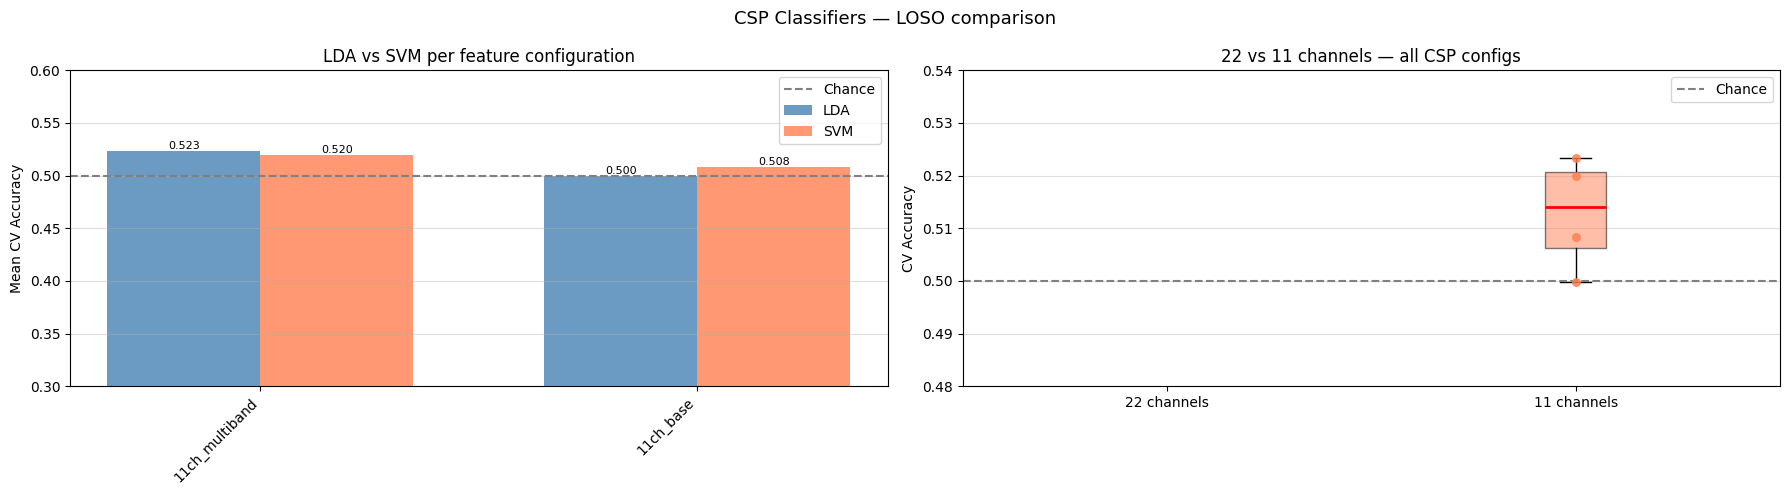


Best CSP model: 11ch_multiband_LDA — 0.5234

=== Visualización LOSO 4 clases ===


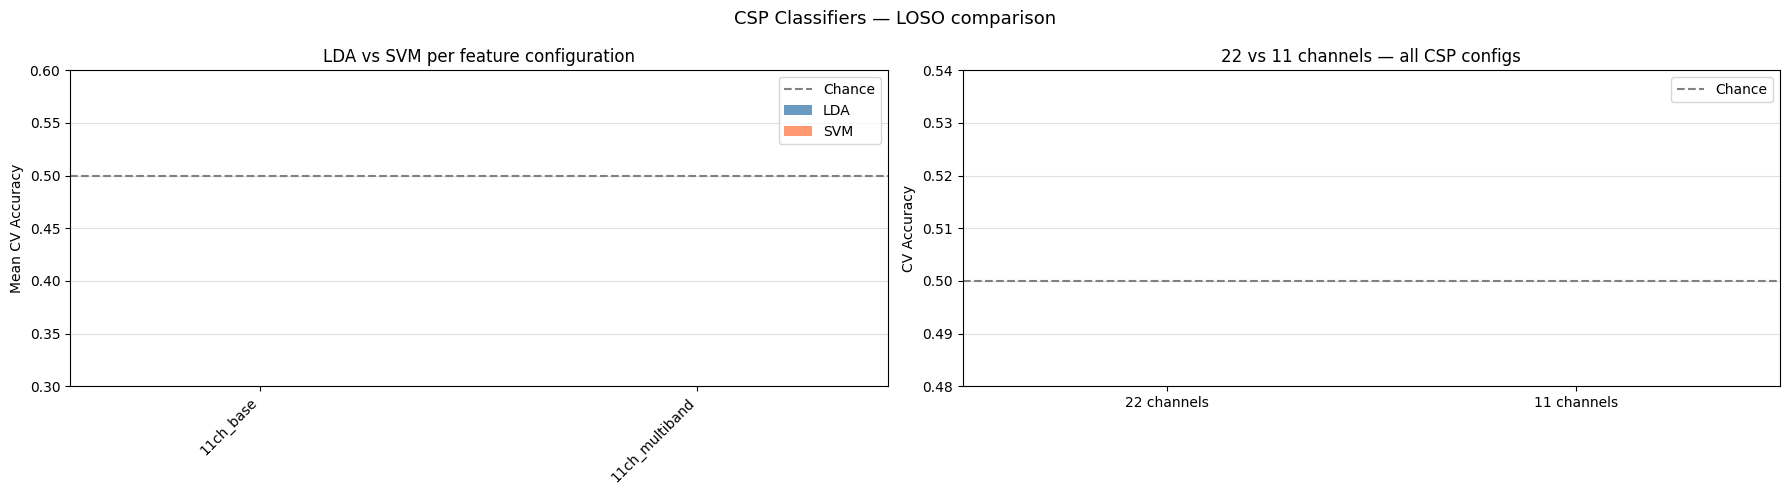


Best CSP model: 11ch_base_SVM — 0.2710


In [16]:
meta_cols = ['config', 'clf', 'classes', 'mean_acc', 'std_acc']
subj_cols = [c for c in df_loso_2.columns if c not in meta_cols]

for n_cls, df_src in [(2, df_loso_2), (4, df_loso_4)]:
    models_vis = {
        'name':           [f"11ch_{r['config']}_{r['clf']}" for _, r in df_src.iterrows()],
        'score':          list(df_src['mean_acc']),
        'subject_scores': df_src[subj_cols].values.tolist(),
    }
    print(f'\n=== Visualización LOSO {n_cls} clases ===')
    visualize_csp(models_vis)

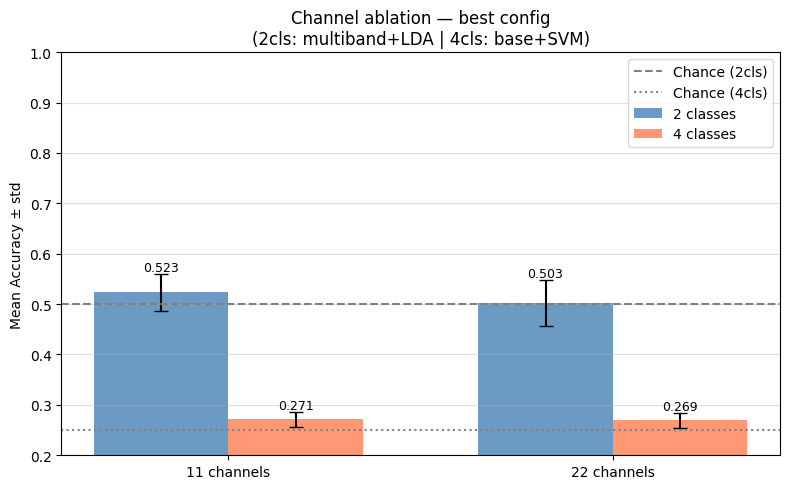

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

abl_2 = df_ch_ablation[df_ch_ablation['classes'] == 2].set_index('channels')
abl_4 = df_ch_ablation[df_ch_ablation['classes'] == 4].set_index('channels')

x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, abl_2.loc[['11ch', '22ch'], 'mean_acc'],
            w, yerr=abl_2.loc[['11ch', '22ch'], 'std_acc'],
            capsize=5, label='2 classes', color='steelblue', alpha=0.8)
b2 = ax.bar(x + w/2, abl_4.loc[['11ch', '22ch'], 'mean_acc'],
            w, yerr=abl_4.loc[['11ch', '22ch'], 'std_acc'],
            capsize=5, label='4 classes', color='coral', alpha=0.8)
ax.bar_label(b1, fmt='%.3f', fontsize=9)
ax.bar_label(b2, fmt='%.3f', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['11 channels', '22 channels'])
ax.axhline(0.5,  color='gray', linestyle='--', label='Chance (2cls)')
ax.axhline(0.25, color='gray', linestyle=':',  label='Chance (4cls)')
ax.set_ylim(0.2, 1.0)
ax.set_ylabel('Mean Accuracy ± std')
ax.set_title(
    f'Channel ablation — best config\n'
    f'(2cls: {best_cfg_2["name"]}+{best_clf_2["name"]} | '
    f'4cls: {best_cfg_4["name"]}+{best_clf_4["name"]})'
)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/CSP_channel_ablation.png', dpi=150, bbox_inches='tight')
plt.show()